# HW5 Offline RL — Report Plots

Generates publication-quality figures from `exp/` logs for Q1 (SAC+BC), Q2 (IQL), and Q3 (FQL).

> **⚠️ Missing data:** Q2 IQL `antsoccer-arena` runs are incomplete (stopped at 600K / 200K steps out of 1M). Those plots will show partial curves; re-run to complete.
>
> **Command to rerun Q2 antsoccer:**
> ```bash
> bash run_q2_iql.sh  # uncomment the antsoccer-arena block first
> ```

In [1]:
import os
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Styling ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

EXP_ROOT = Path('exp')
FIG_DIR  = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Nice environment display names
ENV_LABELS = {
    'antmaze-medium-navigate-singletask-task1-v0': 'AntMaze-Medium (debug)',
    'cube-single-play-singletask-task1-v0':        'Cube-Single',
    'antsoccer-arena-navigate-singletask-task1-v0':'AntSoccer-Arena',
}

# Per-algorithm color palettes (consistent across all plots)
ALGO_COLORS = {
    'sacbc': '#2196F3',   # blue
    'iql':   '#4CAF50',   # green
    'fql':   '#F44336',   # red
}
ALGO_LABELS = {'sacbc': 'SAC+BC', 'iql': 'IQL', 'fql': 'FQL'}

# Color cycles per alpha value (used within each algorithm's alpha-sweep plots)
ALPHA_CMAP = plt.get_cmap('tab10')

print('Setup complete.')

Setup complete.


In [2]:
# ── Data loading helpers ────────────────────────────────────────────────────

def load_experiments(question: str):
    """
    Scan exp/<question>/ and return a list of dicts with:
      algo, env, alpha, train_df, eval_df, flags, path
    For duplicate (algo, env, alpha) keep the one with more eval rows.
    """
    records = []
    q_dir = EXP_ROOT / question
    if not q_dir.exists():
        print(f'Directory {q_dir} not found.')
        return records

    for exp_dir in sorted(q_dir.iterdir()):
        flags_path = exp_dir / 'flags.json'
        eval_path  = exp_dir / 'eval.csv'
        train_path = exp_dir / 'train.csv'
        if not (flags_path.exists() and eval_path.exists()):
            continue

        with open(flags_path) as f:
            flags = json.load(f)

        algo  = flags.get('agent', '?')
        env   = flags.get('env_name', '?')
        alpha = flags.get('agent_kwargs', {}).get('alpha', None)

        eval_df  = pd.read_csv(eval_path)
        train_df = pd.read_csv(train_path) if train_path.exists() else None

        records.append(dict(
            algo=algo, env=env, alpha=alpha,
            eval_df=eval_df, train_df=train_df,
            flags=flags, path=exp_dir
        ))

    # Deduplicate: same (algo, env, alpha) → keep most complete
    deduped = {}
    for r in records:
        key = (r['algo'], r['env'], r['alpha'])
        if key not in deduped or len(r['eval_df']) > len(deduped[key]['eval_df']):
            deduped[key] = r
    return list(deduped.values())


def filter_records(records, algo=None, env=None):
    out = records
    if algo:
        out = [r for r in out if r['algo'] == algo]
    if env:
        out = [r for r in out if r['env'] == env]
    return sorted(out, key=lambda r: r['alpha'])


def smooth(y, w=5):
    """Simple moving average for train curves."""
    if len(y) < w:
        return y
    return np.convolve(y, np.ones(w)/w, mode='same')


# Load all data
q1_recs = load_experiments('q1')
q2_recs = load_experiments('q2')
q3_recs = load_experiments('q3')

print(f'Loaded: Q1={len(q1_recs)}, Q2={len(q2_recs)}, Q3={len(q3_recs)} experiments')

# Report completeness
print('\nCompleteness (max step reached):')
for q, recs in [('Q1', q1_recs), ('Q2', q2_recs), ('Q3', q3_recs)]:
    for r in recs:
        max_step = r['eval_df']['step'].max()
        total    = r['flags'].get('training_steps', 1_000_000)
        status   = '✓' if max_step >= total else f'⚠ {max_step/1e3:.0f}K/{total/1e3:.0f}K'
        env_short = r['env'].split('-')[0] + '-' + r['env'].split('-')[1]
        print(f'  [{q}] {r["algo"]:6s} α={r["alpha"]:6.1f}  {env_short:20s}  {status}')

Loaded: Q1=12, Q2=11, Q3=12 experiments

Completeness (max step reached):
  [Q1] sacbc  α=   1.0  antmaze-medium        ✓
  [Q1] sacbc  α=  10.0  antmaze-medium        ✓
  [Q1] sacbc  α=   3.0  antmaze-medium        ✓
  [Q1] sacbc  α=  30.0  antmaze-medium        ✓
  [Q1] sacbc  α= 100.0  cube-single           ✓
  [Q1] sacbc  α=1000.0  cube-single           ✓
  [Q1] sacbc  α=  30.0  cube-single           ✓
  [Q1] sacbc  α= 300.0  cube-single           ✓
  [Q1] sacbc  α=   1.0  antsoccer-arena       ✓
  [Q1] sacbc  α=  10.0  antsoccer-arena       ✓
  [Q1] sacbc  α=   3.0  antsoccer-arena       ✓
  [Q1] sacbc  α=  30.0  antsoccer-arena       ✓
  [Q2] iql    α=   1.0  antmaze-medium        ✓
  [Q2] iql    α=  10.0  antmaze-medium        ✓
  [Q2] iql    α=   3.0  antmaze-medium        ✓
  [Q2] iql    α=  30.0  antmaze-medium        ✓
  [Q2] iql    α= 100.0  cube-single           ✓
  [Q2] iql    α=1000.0  cube-single           ✓
  [Q2] iql    α=  30.0  cube-single           ✓
  [Q2] iql    

---
## Q1 — SAC+BC (Section 2.2)

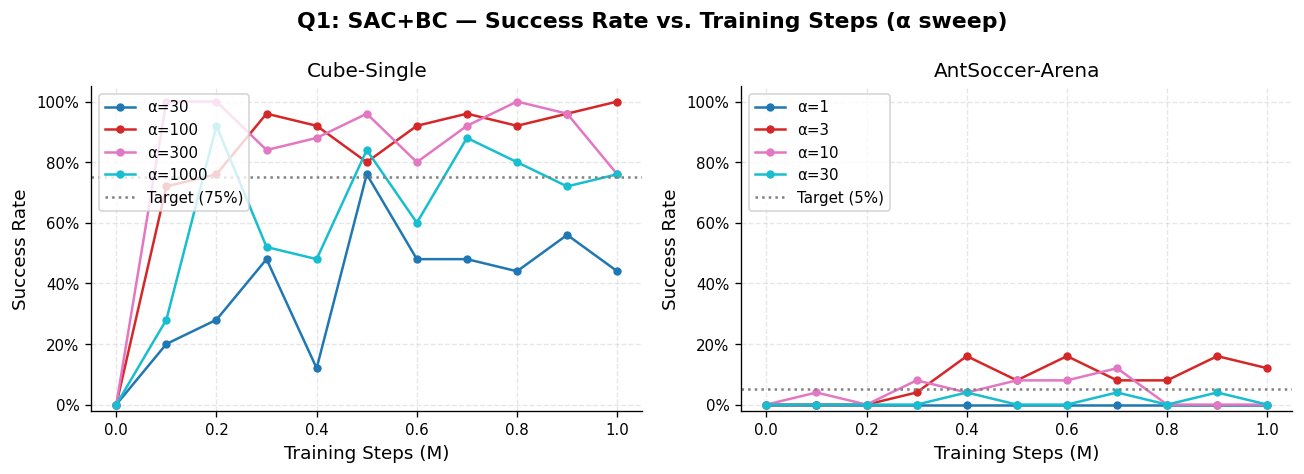

In [3]:
# ── Q1: Success-rate learning curves (alpha sweep) ─────────────────────────

Q1_ENVS = [
    'cube-single-play-singletask-task1-v0',
    'antsoccer-arena-navigate-singletask-task1-v0',
]
TARGETS = {
    'cube-single-play-singletask-task1-v0':        {'sacbc': 0.75, 'iql': 0.60, 'fql': 0.80},
    'antsoccer-arena-navigate-singletask-task1-v0':{'sacbc': 0.05, 'iql': 0.05, 'fql': 0.30},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, env in zip(axes, Q1_ENVS):
    recs = filter_records(q1_recs, algo='sacbc', env=env)
    alphas = sorted(set(r['alpha'] for r in recs))
    colors = {a: ALPHA_CMAP(i / max(len(alphas)-1, 1)) for i, a in enumerate(alphas)}

    for r in recs:
        df = r['eval_df']
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=colors[r['alpha']], marker='o', ms=4,
                label=f'α={r["alpha"]:.0f}')

    # Target success rate line
    target = TARGETS[env]['sacbc']
    ax.axhline(target, ls=':', color='gray', lw=1.5, label=f'Target ({target:.0%})')

    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)')
    ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='upper left', framealpha=0.8)

fig.suptitle('Q1: SAC+BC — Success Rate vs. Training Steps (α sweep)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q1_sacbc_success_curves.pdf')
plt.show()

Best alpha for SAC+BC cube-single: α=100.0 (final success=100%)


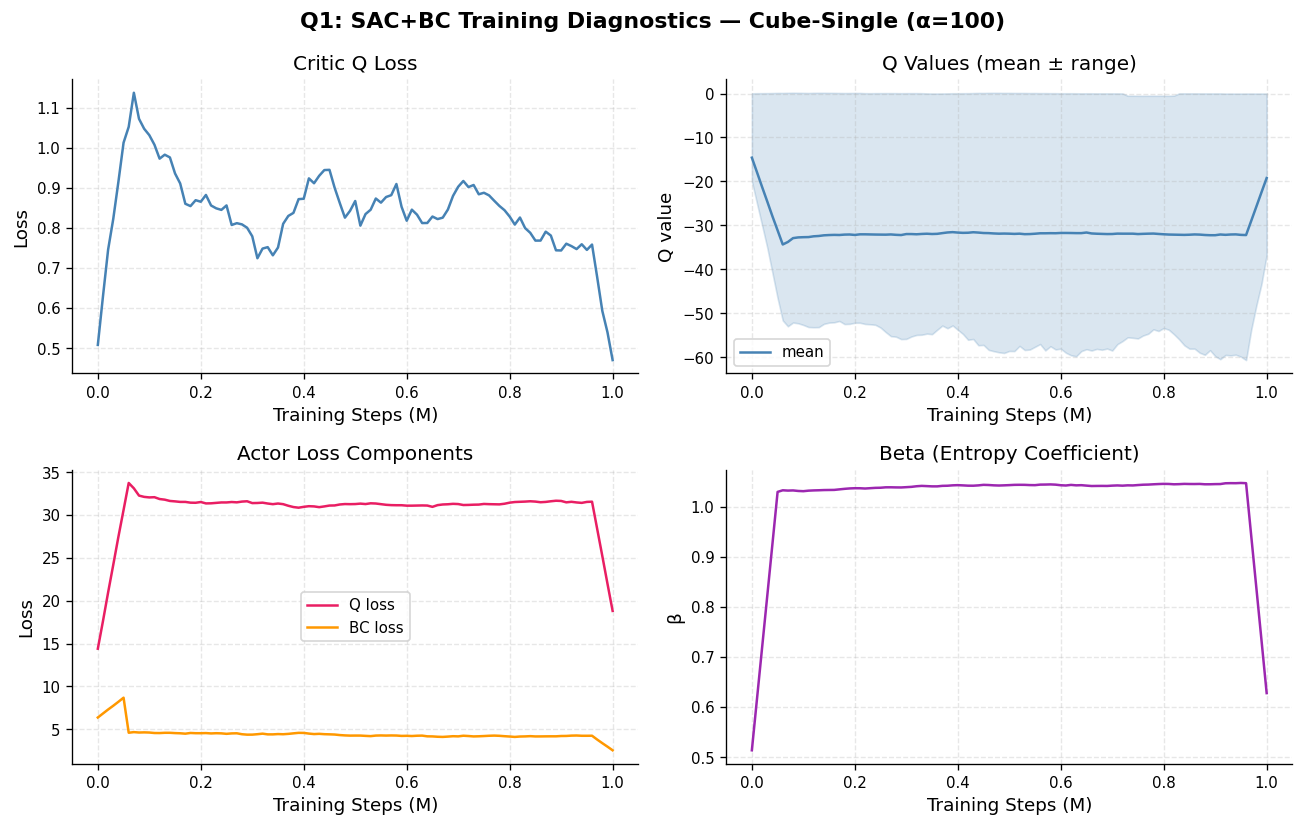

In [4]:
# ── Q1: Training diagnostics for best alpha on cube-single ─────────────────
#  Shows Q values, beta (entropy coeff), and actor loss components.

# Pick best alpha by final success rate
cube_recs = filter_records(q1_recs, algo='sacbc', env='cube-single-play-singletask-task1-v0')
best_q1 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best alpha for SAC+BC cube-single: α={best_q1["alpha"]} '
      f'(final success={best_q1["eval_df"]["eval/success_rate"].iloc[-1]:.0%})')

df = best_q1['train_df']
steps = df['step'] / 1e6
W = 10  # smoothing window

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Q loss
axes[0,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue')
axes[0,0].set_title('Critic Q Loss')
axes[0,0].set_ylabel('Loss')

# Q mean / max / min
axes[0,1].plot(steps, smooth(df['critic/q_mean'].values, W), label='mean', color='steelblue')
axes[0,1].fill_between(steps,
                        smooth(df['critic/q_min'].values, W),
                        smooth(df['critic/q_max'].values, W),
                        alpha=0.2, color='steelblue')
axes[0,1].set_title('Q Values (mean ± range)')
axes[0,1].set_ylabel('Q value')
axes[0,1].legend()

# Actor losses
axes[1,0].plot(steps, smooth(df['actor/q_loss'].values, W),  label='Q loss',  color='#E91E63')
axes[1,0].plot(steps, smooth(df['actor/bc_loss'].values, W), label='BC loss', color='#FF9800')
axes[1,0].set_title('Actor Loss Components')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

# Beta (entropy coefficient)
axes[1,1].plot(steps, smooth(df['beta/beta'].values, W), color='#9C27B0')
axes[1,1].set_title('Beta (Entropy Coefficient)')
axes[1,1].set_ylabel('β')

for ax in axes.flat:
    ax.set_xlabel('Training Steps (M)')

fig.suptitle(f'Q1: SAC+BC Training Diagnostics — Cube-Single (α={best_q1["alpha"]:.0f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q1_sacbc_diagnostics.pdf')
plt.show()

---
## Q2 — IQL (Section 3.2)

> **⚠️ Note:** `antsoccer-arena` curves are incomplete (max 600K steps). Complete the runs before finalizing these plots.

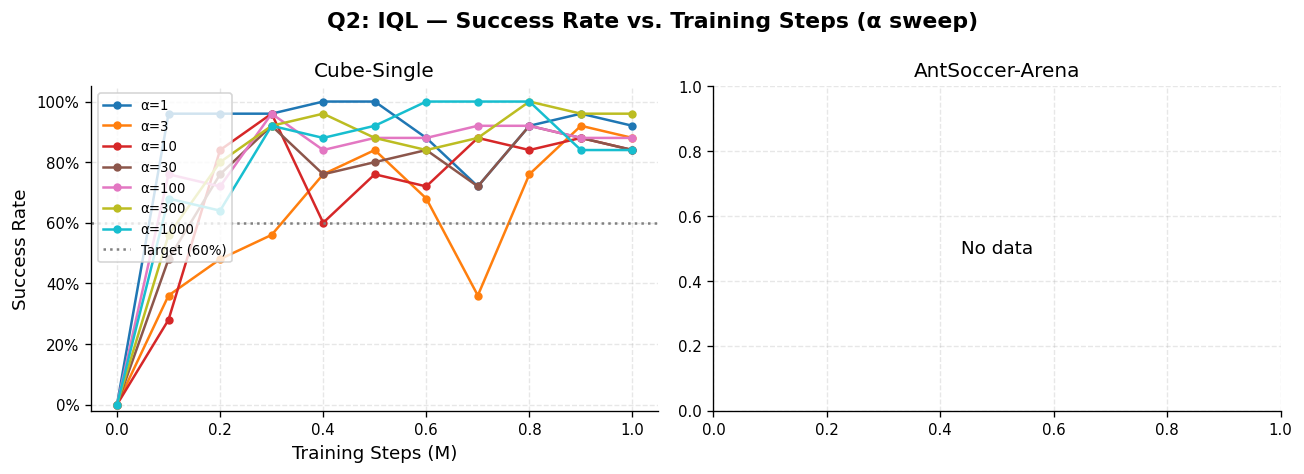

In [5]:
# ── Q2: Success-rate learning curves (alpha sweep) ─────────────────────────

Q2_ENVS = [
    'cube-single-play-singletask-task1-v0',
    'antsoccer-arena-navigate-singletask-task1-v0',
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, env in zip(axes, Q2_ENVS):
    recs = filter_records(q2_recs, algo='iql', env=env)
    if not recs:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(ENV_LABELS[env])
        continue

    alphas = sorted(set(r['alpha'] for r in recs))
    colors = {a: ALPHA_CMAP(i / max(len(alphas)-1, 1)) for i, a in enumerate(alphas)}

    for r in recs:
        df = r['eval_df']
        max_step = df['step'].max()
        incomplete = max_step < r['flags'].get('training_steps', 1_000_000)
        ls = '--' if incomplete else '-'
        lbl = f'α={r["alpha"]:.0f}'
        if incomplete:
            lbl += f' (⚠ {max_step/1e3:.0f}K)'
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=colors[r['alpha']], marker='o', ms=4, ls=ls, label=lbl)

    target = TARGETS[env]['iql']
    ax.axhline(target, ls=':', color='gray', lw=1.5, label=f'Target ({target:.0%})')

    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)')
    ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='upper left', framealpha=0.8, fontsize=8)

fig.suptitle('Q2: IQL — Success Rate vs. Training Steps (α sweep)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_iql_success_curves.pdf')
plt.show()

Best alpha for IQL cube-single: α=300.0 (final success=96%)


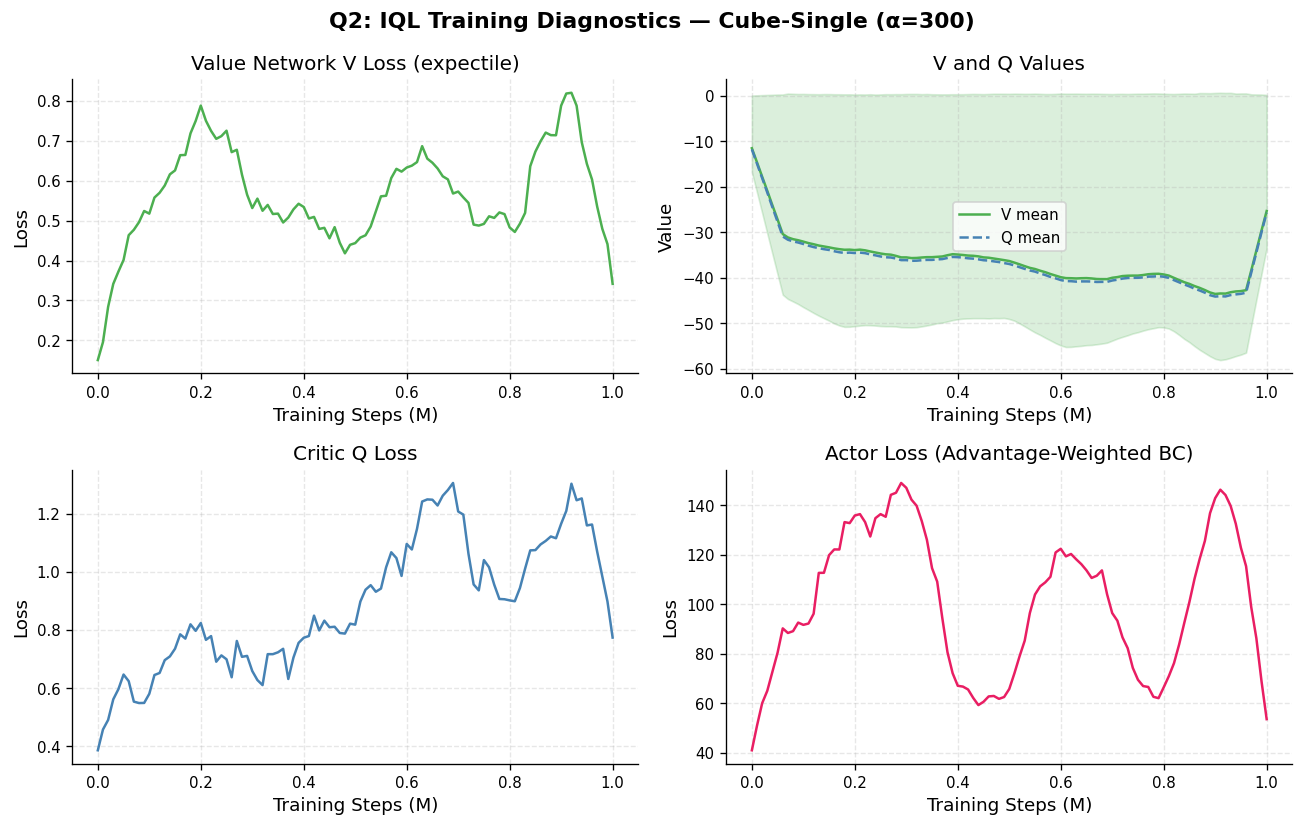

In [6]:
# ── Q2: Training diagnostics for best alpha on cube-single ─────────────────

cube_recs = filter_records(q2_recs, algo='iql', env='cube-single-play-singletask-task1-v0')
best_q2 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best alpha for IQL cube-single: α={best_q2["alpha"]} '
      f'(final success={best_q2["eval_df"]["eval/success_rate"].iloc[-1]:.0%})')

df = best_q2['train_df']
steps = df['step'] / 1e6
W = 10

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# V loss (IQL-specific)
axes[0,0].plot(steps, smooth(df['value/v_loss'].values, W), color='#4CAF50')
axes[0,0].set_title('Value Network V Loss (expectile)')
axes[0,0].set_ylabel('Loss')

# V mean / max / min
axes[0,1].plot(steps, smooth(df['value/v_mean'].values, W), label='V mean', color='#4CAF50')
axes[0,1].fill_between(steps,
                        smooth(df['value/v_min'].values, W),
                        smooth(df['value/v_max'].values, W),
                        alpha=0.2, color='#4CAF50')
# Overlay Q mean
axes[0,1].plot(steps, smooth(df['critic/q_mean'].values, W),
               label='Q mean', color='steelblue', ls='--')
axes[0,1].set_title('V and Q Values')
axes[0,1].set_ylabel('Value')
axes[0,1].legend()

# Critic Q loss
axes[1,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue')
axes[1,0].set_title('Critic Q Loss')
axes[1,0].set_ylabel('Loss')

# Actor loss (advantage-weighted BC)
axes[1,1].plot(steps, smooth(df['actor/actor_loss'].values, W), color='#E91E63')
axes[1,1].set_title('Actor Loss (Advantage-Weighted BC)')
axes[1,1].set_ylabel('Loss')

for ax in axes.flat:
    ax.set_xlabel('Training Steps (M)')

fig.suptitle(f'Q2: IQL Training Diagnostics — Cube-Single (α={best_q2["alpha"]:.0f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_iql_diagnostics.pdf')
plt.show()

---
## Q3 — FQL (Section 4.4)

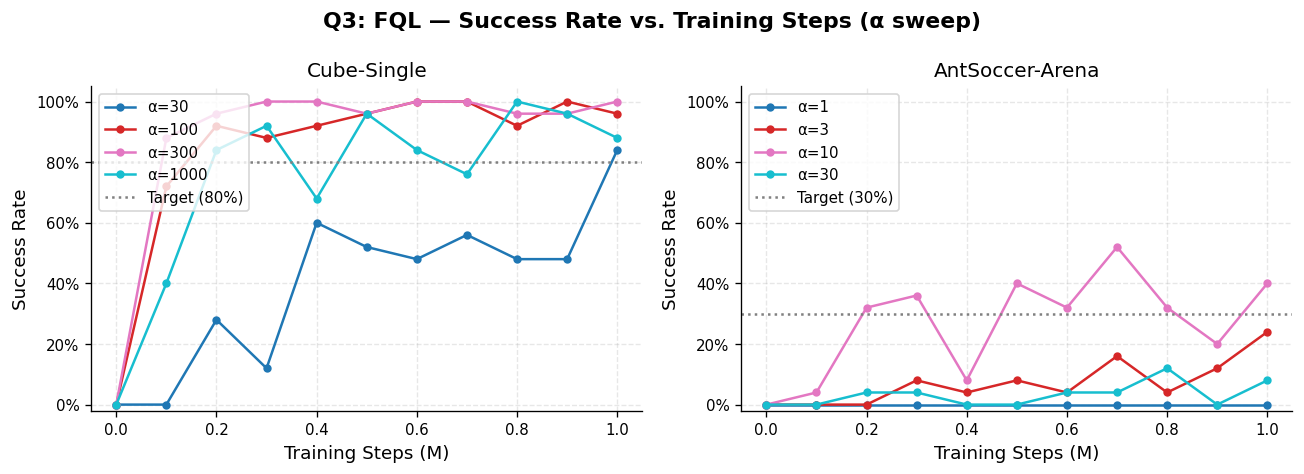

In [7]:
# ── Q3: Success-rate learning curves (alpha sweep) ─────────────────────────

Q3_ENVS = [
    'cube-single-play-singletask-task1-v0',
    'antsoccer-arena-navigate-singletask-task1-v0',
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, env in zip(axes, Q3_ENVS):
    recs = filter_records(q3_recs, algo='fql', env=env)
    alphas = sorted(set(r['alpha'] for r in recs))
    colors = {a: ALPHA_CMAP(i / max(len(alphas)-1, 1)) for i, a in enumerate(alphas)}

    for r in recs:
        df = r['eval_df']
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=colors[r['alpha']], marker='o', ms=4,
                label=f'α={r["alpha"]:.0f}')

    target = TARGETS[env]['fql']
    ax.axhline(target, ls=':', color='gray', lw=1.5, label=f'Target ({target:.0%})')

    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)')
    ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='upper left', framealpha=0.8)

fig.suptitle('Q3: FQL — Success Rate vs. Training Steps (α sweep)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_fql_success_curves.pdf')
plt.show()

Best alpha for FQL cube-single: α=300.0 (final success=100%)


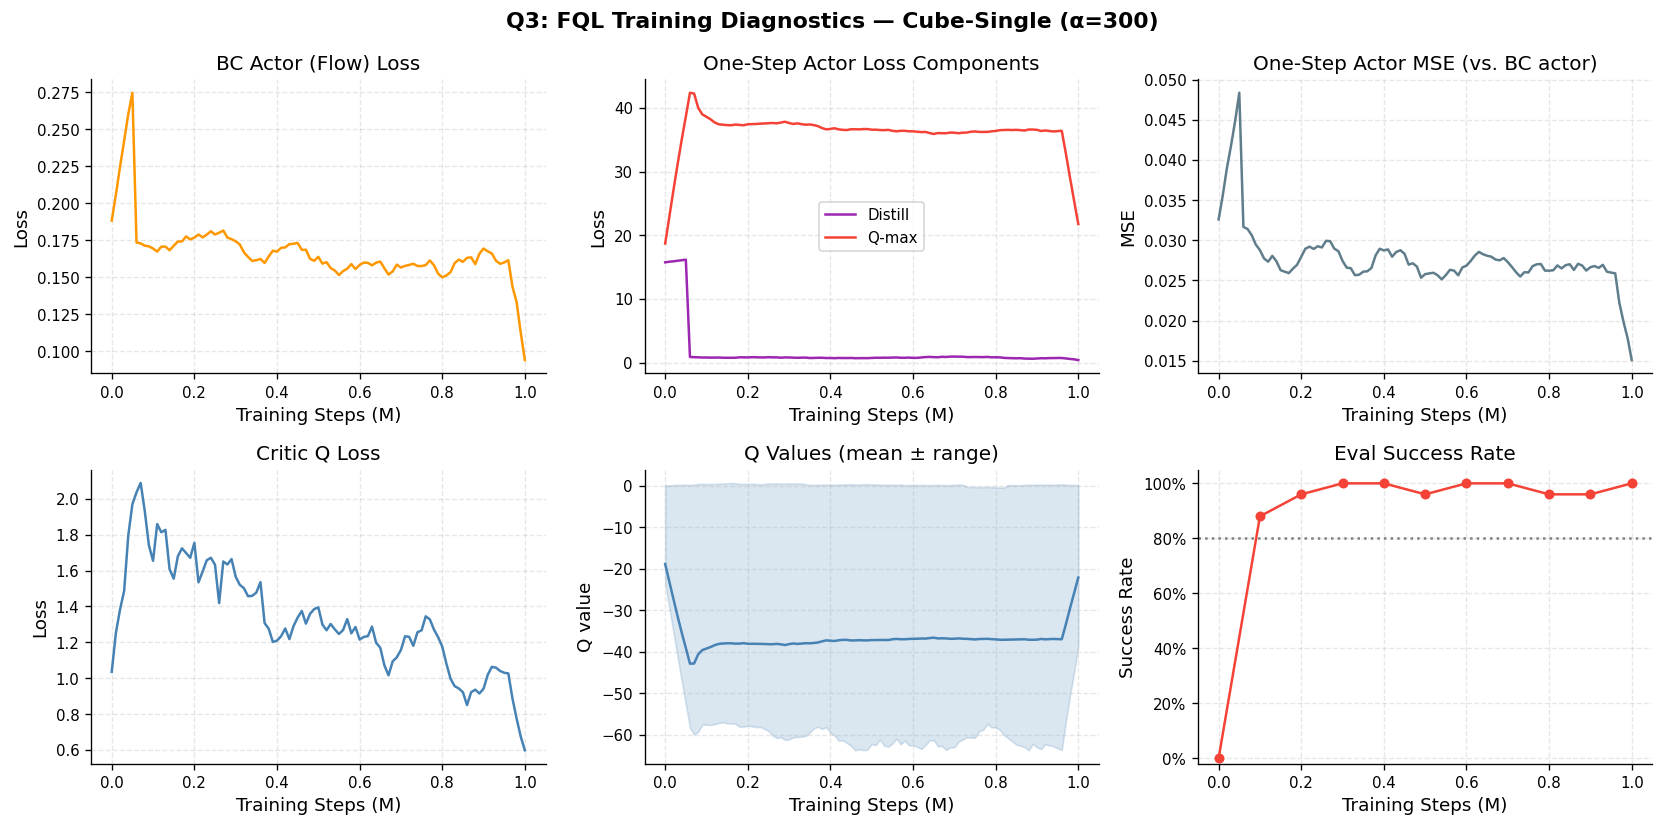

In [8]:
# ── Q3: FQL training diagnostics for best alpha on cube-single ─────────────

cube_recs = filter_records(q3_recs, algo='fql', env='cube-single-play-singletask-task1-v0')
best_q3 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best alpha for FQL cube-single: α={best_q3["alpha"]} '
      f'(final success={best_q3["eval_df"]["eval/success_rate"].iloc[-1]:.0%})')

df = best_q3['train_df']
steps = df['step'] / 1e6
W = 10

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# BC actor flow loss
axes[0,0].plot(steps, smooth(df['bc_actor/loss'].values, W), color='#FF9800')
axes[0,0].set_title('BC Actor (Flow) Loss')
axes[0,0].set_ylabel('Loss')

# One-step actor: distillation vs Q loss
axes[0,1].plot(steps, smooth(df['onestep_actor/distill_loss'].values, W),
               label='Distill', color='#9C27B0')
axes[0,1].plot(steps, smooth(df['onestep_actor/q_loss'].values, W),
               label='Q-max', color='#F44336')
axes[0,1].set_title('One-Step Actor Loss Components')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

# One-step actor MSE (distance from BC actor)
axes[0,2].plot(steps, smooth(df['onestep_actor/mse'].values, W), color='#607D8B')
axes[0,2].set_title('One-Step Actor MSE (vs. BC actor)')
axes[0,2].set_ylabel('MSE')

# Critic Q loss
axes[1,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue')
axes[1,0].set_title('Critic Q Loss')
axes[1,0].set_ylabel('Loss')

# Q mean / range
axes[1,1].plot(steps, smooth(df['critic/q_mean'].values, W), color='steelblue', label='mean')
axes[1,1].fill_between(steps,
                        smooth(df['critic/q_min'].values, W),
                        smooth(df['critic/q_max'].values, W),
                        alpha=0.2, color='steelblue')
axes[1,1].set_title('Q Values (mean ± range)')
axes[1,1].set_ylabel('Q value')

# Eval success overlaid
eval_df = best_q3['eval_df']
axes[1,2].plot(eval_df['step']/1e6, eval_df['eval/success_rate'],
               color='#F44336', marker='o', ms=5)
axes[1,2].axhline(TARGETS['cube-single-play-singletask-task1-v0']['fql'],
                  ls=':', color='gray', lw=1.5)
axes[1,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,2].set_title('Eval Success Rate')
axes[1,2].set_ylabel('Success Rate')
axes[1,2].set_ylim(-0.02, 1.05)

for ax in axes.flat:
    ax.set_xlabel('Training Steps (M)')

fig.suptitle(f'Q3: FQL Training Diagnostics — Cube-Single (α={best_q3["alpha"]:.0f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_fql_diagnostics.pdf')
plt.show()

---
## Cross-Algorithm Comparison

Best alpha for each algorithm on each required environment.

In [9]:
# ── Pick best run per (algo, env) across all questions ─────────────────────

all_recs = q1_recs + q2_recs + q3_recs

def best_run(algo, env):
    recs = filter_records(all_recs, algo=algo, env=env)
    # Only consider runs that completed (or are most complete)
    if not recs:
        return None
    return max(recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])


# Summary table
print(f"{'Algorithm':10s}  {'Environment':45s}  {'Best α':8s}  {'Final Success':>14s}")
print('-' * 85)
for algo, label in ALGO_LABELS.items():
    for env in ['cube-single-play-singletask-task1-v0',
                'antsoccer-arena-navigate-singletask-task1-v0']:
        r = best_run(algo, env)
        if r:
            final = r['eval_df']['eval/success_rate'].iloc[-1]
            max_step = r['eval_df']['step'].max()
            total = r['flags'].get('training_steps', 1_000_000)
            flag = '' if max_step >= total else f' ⚠({max_step/1e3:.0f}K)'
            print(f"{label:10s}  {ENV_LABELS[env]:45s}  {r['alpha']:8.1f}  {final:>13.0%}{flag}")
        else:
            print(f"{label:10s}  {ENV_LABELS[env]:45s}  {'N/A':8s}  {'N/A':>14s}")

Algorithm   Environment                                    Best α     Final Success
-------------------------------------------------------------------------------------
SAC+BC      Cube-Single                                       100.0           100%
SAC+BC      AntSoccer-Arena                                     3.0            12%
IQL         Cube-Single                                       300.0            96%
IQL         AntSoccer-Arena                                N/A                  N/A
FQL         Cube-Single                                       300.0           100%
FQL         AntSoccer-Arena                                    10.0            40%


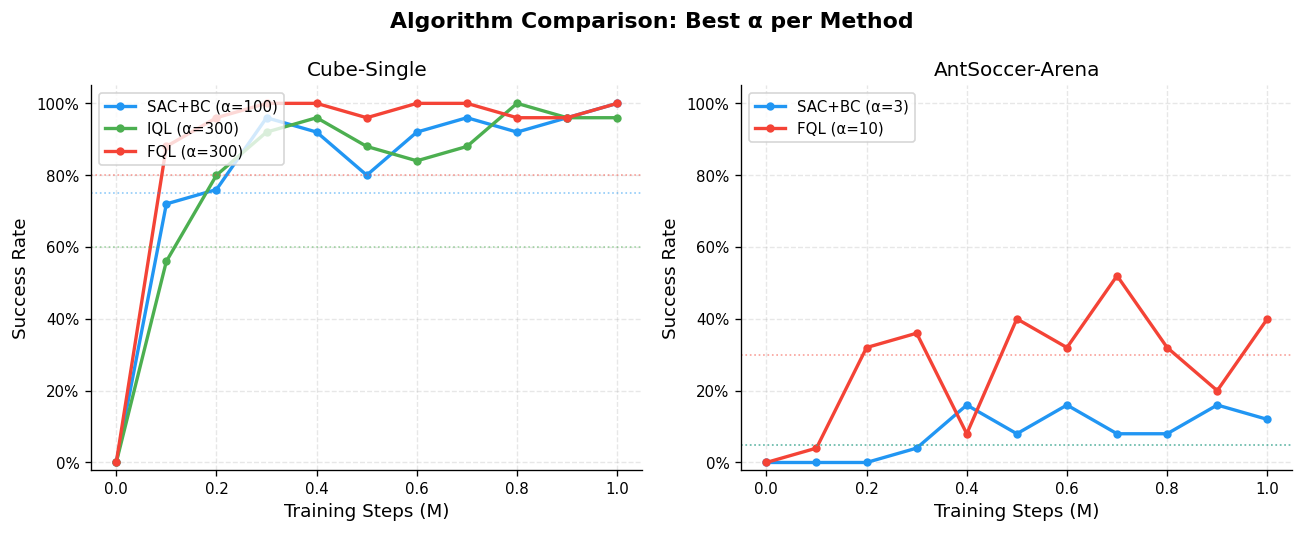

In [10]:
# ── Comparison: success curves for all three algorithms ────────────────────

COMP_ENVS = [
    'cube-single-play-singletask-task1-v0',
    'antsoccer-arena-navigate-singletask-task1-v0',
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

for ax, env in zip(axes, COMP_ENVS):
    for algo, label in ALGO_LABELS.items():
        r = best_run(algo, env)
        if r is None:
            continue
        df = r['eval_df']
        max_step = df['step'].max()
        total = r['flags'].get('training_steps', 1_000_000)
        incomplete = max_step < total
        ls = '--' if incomplete else '-'
        lbl = f'{label} (α={r["alpha"]:.0f})'
        if incomplete:
            lbl += f' ⚠{max_step/1e3:.0f}K'
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=ALGO_COLORS[algo], marker='o', ms=4, ls=ls,
                linewidth=2, label=lbl)

    # Target lines per algorithm
    for algo in ALGO_LABELS:
        t = TARGETS[env][algo]
        ax.axhline(t, ls=':', color=ALGO_COLORS[algo], lw=1, alpha=0.5)

    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)')
    ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc='upper left', framealpha=0.8)

fig.suptitle('Algorithm Comparison: Best α per Method', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_all_algorithms.pdf')
plt.show()

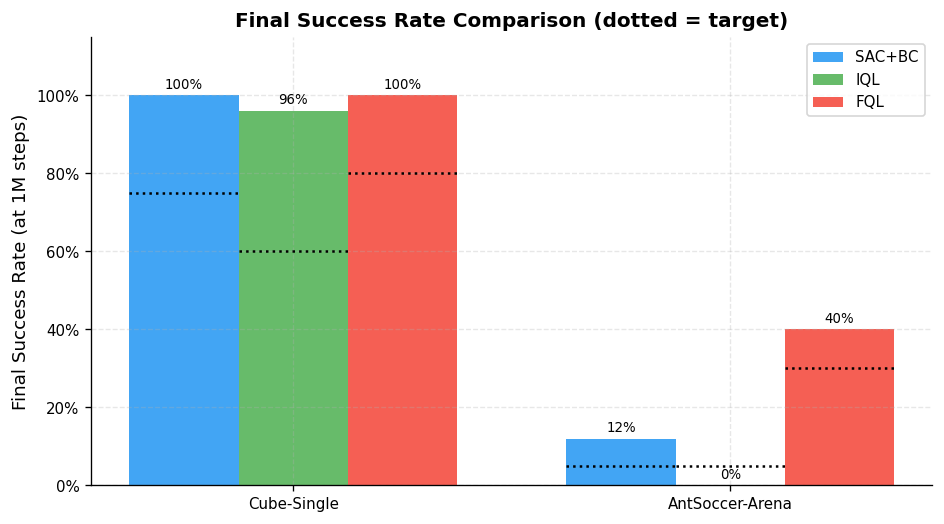

In [11]:
# ── Bar chart: Final success rate by algorithm ─────────────────────────────

COMP_ENVS_SHORT = {
    'cube-single-play-singletask-task1-v0':         'Cube-Single',
    'antsoccer-arena-navigate-singletask-task1-v0': 'AntSoccer-Arena',
}

algos = list(ALGO_LABELS.keys())
envs  = list(COMP_ENVS_SHORT.keys())
x = np.arange(len(envs))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, algo in enumerate(algos):
    values = []
    for env in envs:
        r = best_run(algo, env)
        values.append(r['eval_df']['eval/success_rate'].iloc[-1] if r else 0.0)
    bars = ax.bar(x + (i - 1) * width, values, width,
                  label=ALGO_LABELS[algo], color=ALGO_COLORS[algo], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=8)

# Target lines
for i, env in enumerate(envs):
    for algo in algos:
        t = TARGETS[env][algo]
        ax.plot([x[i] + (algos.index(algo) - 1)*width - width/2,
                 x[i] + (algos.index(algo) - 1)*width + width/2],
                [t, t], color='black', lw=1.5, ls=':')

ax.set_xticks(x)
ax.set_xticklabels(list(COMP_ENVS_SHORT.values()))
ax.set_ylabel('Final Success Rate (at 1M steps)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title('Final Success Rate Comparison (dotted = target)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_bar_chart.pdf')
plt.show()

---
## Optional: Alpha Sensitivity Analysis

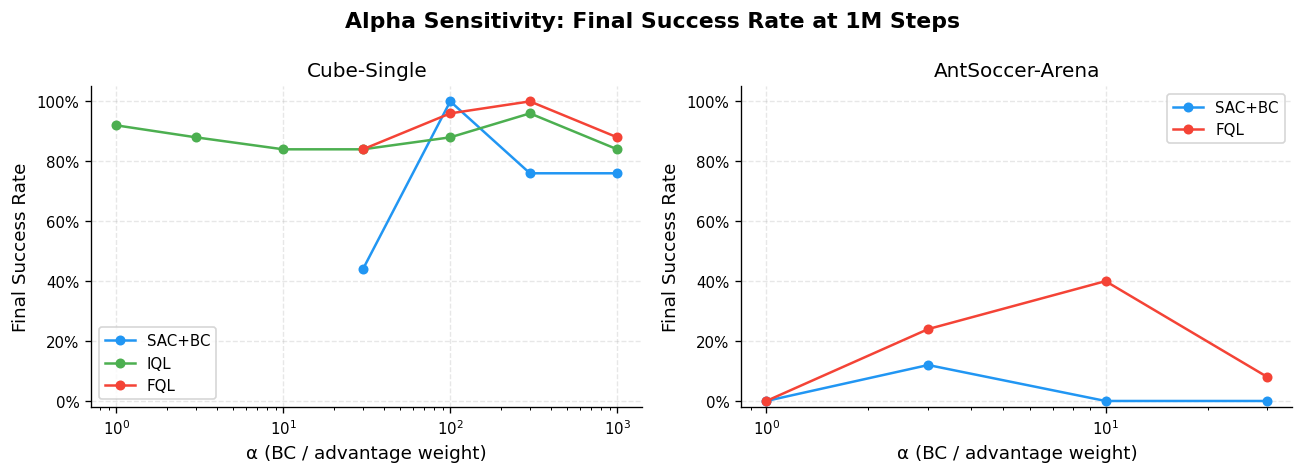

In [12]:
# ── Alpha sensitivity: final success rate vs alpha value ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

all_q_recs = [('sacbc', q1_recs), ('iql', q2_recs), ('fql', q3_recs)]

for ax, env in zip(axes, COMP_ENVS):
    for algo, recs in all_q_recs:
        runs = filter_records(recs, algo=algo, env=env)
        if not runs:
            continue
        alphas = [r['alpha'] for r in runs]
        finals = [r['eval_df']['eval/success_rate'].iloc[-1] for r in runs]
        # Sort by alpha
        pairs = sorted(zip(alphas, finals))
        ax.plot([p[0] for p in pairs], [p[1] for p in pairs],
                color=ALGO_COLORS[algo], marker='o', ms=5, linewidth=1.5,
                label=ALGO_LABELS[algo])

    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('α (BC / advantage weight)')
    ax.set_ylabel('Final Success Rate')
    ax.set_xscale('log')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.02, 1.05)
    ax.legend()

fig.suptitle('Alpha Sensitivity: Final Success Rate at 1M Steps', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'alpha_sensitivity.pdf')
plt.show()

In [13]:
# ── Summary: list all saved figures ────────────────────────────────────────

print('Saved figures:')
for f in sorted(FIG_DIR.glob('*.pdf')):
    print(f'  figures/{f.name}')

Saved figures:
  figures/alpha_sensitivity.pdf
  figures/comparison_all_algorithms.pdf
  figures/comparison_bar_chart.pdf
  figures/q1_sacbc_diagnostics.pdf
  figures/q1_sacbc_success_curves.pdf
  figures/q2_iql_diagnostics.pdf
  figures/q2_iql_success_curves.pdf
  figures/q3_fql_diagnostics.pdf
  figures/q3_fql_success_curves.pdf
